In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import os

# Create images folder
os.makedirs('images', exist_ok=True)

# Set style
sns.set(style="whitegrid")

In [2]:
# Load Data
df = pd.read_csv('dataset/titanic.csv')

# 1. Handle Missing Values
df['Age'].fillna(df['Age'].median(), inplace=True) # Fill Age with median
df.drop('Cabin', axis=1, inplace=True)             # Drop Cabin (too many missing)
df.dropna(inplace=True)                            # Drop rows with missing Embarked

# 2. Drop columns that won't help prediction
df.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)

print("Data Cleaned!")
print(df.head())

Data Cleaned!
   Survived  Pclass     Sex   Age  SibSp  Parch     Fare Embarked
0         0       3    male  22.0      1      0   7.2500        S
1         1       1  female  38.0      1      0  71.2833        C
2         1       3  female  26.0      0      0   7.9250        S
3         1       1  female  35.0      1      0  53.1000        S
4         0       3    male  35.0      0      0   8.0500        S


C:\Users\Abin\AppData\Local\Temp\ipykernel_3200\1455025192.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True) # Fill Age with median


In [3]:
# Convert 'Sex' to numbers (Male=1, Female=0 or similar)
sex = pd.get_dummies(df['Sex'], drop_first=True)

# Convert 'Embarked' to numbers
embark = pd.get_dummies(df['Embarked'], drop_first=True)

# Drop the old text columns and add the new numerical ones
df.drop(['Sex', 'Embarked'], axis=1, inplace=True)
df = pd.concat([df, sex, embark], axis=1)

print("Data is now fully numerical:")
print(df.head())

Data is now fully numerical:
   Survived  Pclass   Age  SibSp  Parch     Fare   male      Q      S
0         0       3  22.0      1      0   7.2500   True  False   True
1         1       1  38.0      1      0  71.2833  False  False  False
2         1       3  26.0      0      0   7.9250  False  False   True
3         1       1  35.0      1      0  53.1000  False  False   True
4         0       3  35.0      0      0   8.0500   True  False   True


In [4]:
# 1. Define Features (X) and Target (y)
X = df.drop('Survived', axis=1) # All columns except Survived
y = df['Survived']              # Only the Survived column

# 2. Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize and Train Logistic Regression
logmodel = LogisticRegression(max_iter=1000)
logmodel.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


Model Accuracy: 78.09%


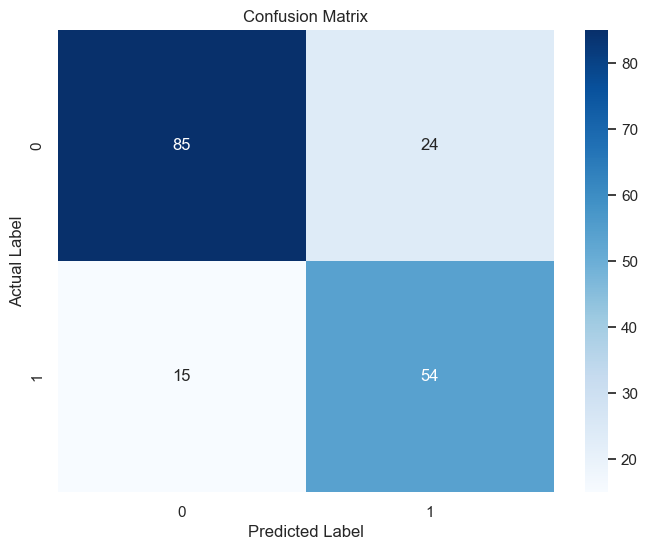

              precision    recall  f1-score   support

           0       0.85      0.78      0.81       109
           1       0.69      0.78      0.73        69

    accuracy                           0.78       178
   macro avg       0.77      0.78      0.77       178
weighted avg       0.79      0.78      0.78       178



In [5]:
# Make Predictions
predictions = logmodel.predict(X_test)

# 1. Accuracy Score
acc = accuracy_score(y_test, predictions)
print(f"Model Accuracy: {acc*100:.2f}%")

# 2. Confusion Matrix Heatmap
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.savefig('images/confusion_matrix.png')
plt.show()

# 3. Detailed Report
print(classification_report(y_test, predictions))

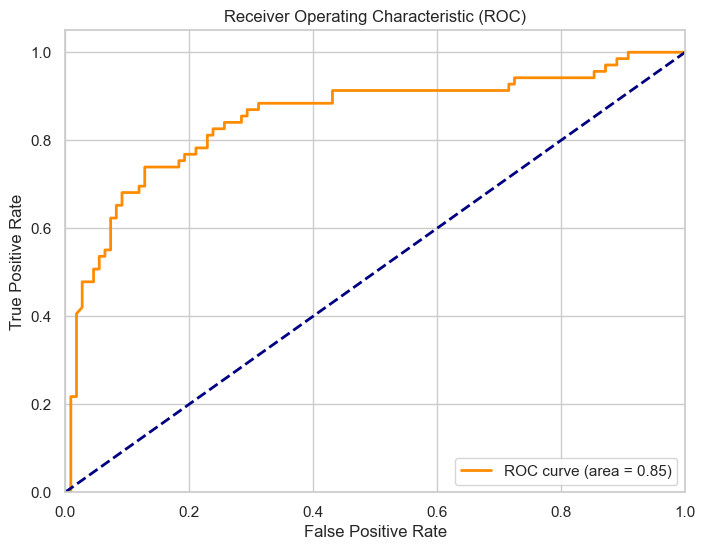

In [6]:
from sklearn.metrics import roc_curve, auc

# Get probabilities instead of just Yes/No
y_prob = logmodel.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.savefig('images/roc_curve.png')
plt.show()

In [7]:
# Helper function to predict custom data
def predict_survival(pclass, age, sibsp, parch, fare, male_gender, q_embark, s_embark):
    # Create a dataframe with the same columns as X
    custom_data = pd.DataFrame([[pclass, age, sibsp, parch, fare, male_gender, q_embark, s_embark]],
                               columns=X.columns)
    prediction = logmodel.predict(custom_data)[0]
    prob = logmodel.predict_proba(custom_data)[0][1]

    if prediction == 1:
        return f"Survived! (Probability: {prob:.2f})"
    else:
        return f"Did not survive. (Probability: {prob:.2f})"

# TEST IT: 3rd Class, Age 22, Male, Cheap Fare... (Jack from the movie?)
print("Jack's Fate:", predict_survival(3, 22, 0, 0, 7.25, 1, 0, 1))

# TEST IT: 1st Class, Age 20, Female, Expensive Fare... (Rose?)
print("Rose's Fate:", predict_survival(1, 17, 0, 1, 100, 0, 0, 1))

Jack's Fate: Did not survive. (Probability: 0.13)
Rose's Fate: Survived! (Probability: 0.96)


In [8]:
from sklearn.model_selection import cross_val_score

# Run 10-Fold Cross-Validation
scores = cross_val_score(logmodel, X, y, cv=10, scoring='accuracy')

print("Cross-Validation Scores:", scores)
print(f"Mean Accuracy: {scores.mean()*100:.2f}%")
print(f"Standard Deviation: {scores.std()*100:.2f}%")

Cross-Validation Scores: [0.78651685 0.79775281 0.74157303 0.82022472 0.78651685 0.76404494
 0.78651685 0.78651685 0.80898876 0.84090909]
Mean Accuracy: 79.20%
Standard Deviation: 2.64%


In [9]:
from sklearn.model_selection import GridSearchCV

# Define parameters to test
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'], # l2 is standard for Logistic Regression
    'solver': ['lbfgs', 'liblinear']
}

# Initialize Grid Search
grid = GridSearchCV(LogisticRegression(max_iter=1000), param_grid, refit=True, verbose=0)
grid.fit(X_train, y_train)

# Print best parameters
print(f"Best Hyperparameters: {grid.best_params_}")
print(f"Best Accuracy Score: {grid.best_score_*100:.2f}%")

# Test the "Best" model
grid_predictions = grid.predict(X_test)
print(classification_report(y_test, grid_predictions))

Best Hyperparameters: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
Best Accuracy Score: 80.30%
              precision    recall  f1-score   support

           0       0.84      0.83      0.84       109
           1       0.74      0.75      0.75        69

    accuracy                           0.80       178
   macro avg       0.79      0.79      0.79       178
weighted avg       0.80      0.80      0.80       178



C:\Users\Abin\AppData\Local\Temp\ipykernel_3200\3904384302.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=coefs['Coefficient'], y=coefs.index, palette='viridis')


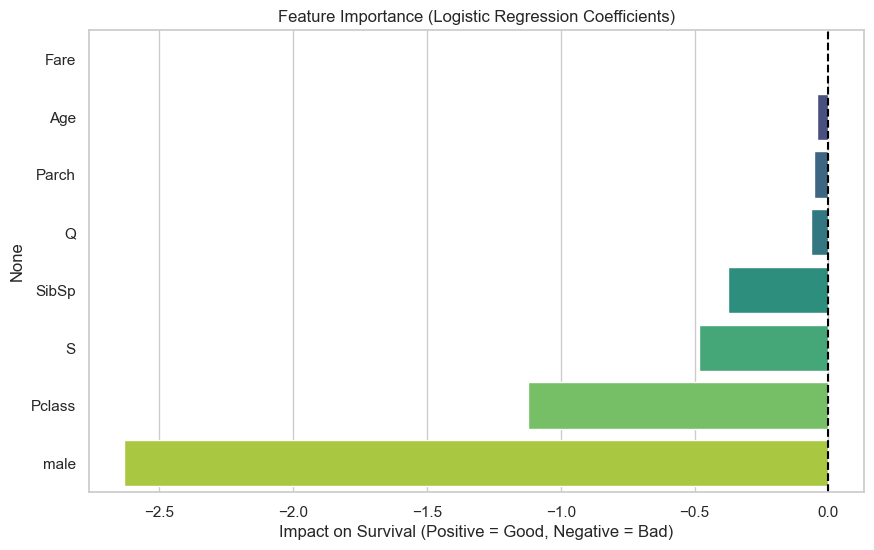

In [10]:
# Get coefficients from the best model (or original logmodel)
coefs = pd.DataFrame(logmodel.coef_[0], index=X.columns, columns=['Coefficient'])
coefs = coefs.sort_values(by='Coefficient', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=coefs['Coefficient'], y=coefs.index, palette='viridis')
plt.title('Feature Importance (Logistic Regression Coefficients)')
plt.xlabel('Impact on Survival (Positive = Good, Negative = Bad)')
plt.axvline(x=0, color='black', linestyle='--')
plt.savefig('images/feature_importance.png')
plt.show()